# ERO1

In [2]:
#Drone

import networkx as nx
import matplotlib.pyplot as plt
import itertools
from networkx.algorithms.matching import max_weight_matching
import random
import pickle
import copy

#Animation
import time
from IPython.display import clear_output

## Partie 1: Drone

#### I. Importer le graphe d'un quartier

In [3]:
def import_G(filename):    
    with open(filename, 'rb') as f:
        G = pickle.load(f).to_undirected()
    return G

start = time.time()
quartier = "plateau_mont_royal"

G = import_G("./database/maps/" + quartier.replace(" ", "-") + ".gpickle")
G_aug = import_G("./database/eulerized_maps/" + quartier.replace(" ", "-") + "_aug.gpickle")

end = time.time()
print("Time elapsed: ", end - start, "s")

Time elapsed:  0.8923008441925049 s


#### II. Enneiger

In [4]:
def snowize(G, p = 0.5):
    for u, v in G.edges():
        for key in G[u][v]:
            if (random.random() <= p):
                G[u][v][key]['snow'] = 1
            else:
                G[u][v][key]['snow'] = 0
    return G

G = snowize(G, 0.1)
#G_bis = copie de G en Multigraph
G_bis = nx.MultiGraph(G)

#### III. Trouver la neige et rendre une liste

In [5]:
start = time.time()

def snow_roads(G_aug, G_bis):
    circuit = list(nx.eulerian_circuit(G_aug))
    edges = []
    for i, (u, v) in enumerate(circuit):
        for key in G_bis[u][v]:
            if G_bis[u][v][key]['snow']:
                edges.append((u, v, key))

    return edges

snow_edges = snow_roads(G_aug, G_bis)
print("Time elapsed: ", time.time() - start, "s")

Time elapsed:  0.09694409370422363 s


#### IV. Animer le trajet du drone avec la neige en bleu

In [6]:
def animation(G_aug, arrondissement, snow_edges):
    # Position geographique reelle
    pos = {node: (data['x'], data['y']) for node, data in G_aug.nodes(data=True)}
    
    circuit = list(nx.eulerian_circuit(G_aug))
    
    edges_drawn = []
    
    for i, edge in enumerate(circuit):
        edges_drawn.append(edge)
    
        clear_output(wait=True)
        plt.figure(figsize=(12, 12))
    
        options = {"edgecolors": "tab:gray", "node_size": 0.5, "alpha": 0.8}
        nx.draw_networkx_nodes(G_aug, pos, node_color="tab:blue", **options)
    
        nx.draw_networkx_edges(G_aug, pos, width=0.5, alpha=0.2, edge_color="gray")
    
        nx.draw_networkx_edges(
            G_aug,
            pos,
            edgelist=snow_edges,
            width=1,
            alpha=0.5,
            edge_color="tab:blue",
        )
        
        nx.draw_networkx_edges(
            G_aug,
            pos,
            edgelist=edges_drawn,
            width=2,
            alpha=0.9,
            edge_color="tab:red",
        )
    
        plt.title(f"{arrondissement} - Étape {i+1} / {len(circuit)}", fontsize=14)
        plt.axis("off")
        plt.tight_layout()
        plt.show()

animation(G_aug, quartier, snow_edges)

KeyboardInterrupt: 

## Partie 2 : La Deneigeuse

#### I. Charger le graphe d'un quartier comme graphe dirigé

In [7]:
start = time.time()
with open("./database/maps/" + quartier.replace(" ", "-") + ".gpickle", 'rb') as f:
    G = pickle.load(f).to_directed()
print("Time elapsed: ", time.time() - start, "s")

Time elapsed:  0.31414103507995605 s


#### II. Vérifier que les arrêtes enneigées détectées par le drone sont dans le bon sens

In [8]:
def fix_edges(G, edges):
    for i in range(len(edges)):
        if not edges[i][1] in G[edges[i][0]]:
            edges[i] = (edges[i][1], edges[i][0], edges[i][2])

start = time.time()
fix_edges(G, snow_edges)
print("Time elapsed: ", time.time() - start, "s")

Time elapsed:  0.0008480548858642578 s


#### III. Charger Floyd-Warshall depuis la base de donnée ou le calculer et le stocker

In [9]:
import os

start = time.time()

# if not already calculated, calculate and then store
predecessores, weights = None, None

# name of the archive where the result of floyd warshall are saved
FW_file = "database/floyd_warshall_data/" + quartier + "-FWR.pkl"

if not os.path.exists(FW_file):

    predecessors, weights = nx.floyd_warshall_predecessor_and_distance(G, weight="length")

    predecessors_clean = {u: dict(v) for u, v in predecessors.items()}
    weights_clean = {u: dict(v) for u, v in weights.items()}

    with open(FW_file, "wb") as f:
        pickle.dump((predecessors_clean, weights_clean), f)
else:
    with open(FW_file, "rb") as f:
        predecessors, weights = pickle.load(f)

floyd_results = (weights, predecessors)
print("Time elapsed: ", time.time() - start, "s")

Time elapsed:  0.6851720809936523 s


#### IV. Diviser la liste de rue enneigées en 4 listes réparties géographiquement

In [10]:
def is_accessible(G, floyd_weight, node, max_cpt):
    cpt = 0
    for n in G.nodes():
        if floyd_weight[n][node] != float('inf'):
            cpt += 1
            if cpt >= max_cpt:
                return True
    return False

def find_center(G, floyd_weight):
    sx = 0
    sy = 0
    cpt = 0
    for _, data in G.nodes(data=True):
        if "x" in data and "y" in data:
            cpt += 1
            sx += data["x"]
            sy += data["y"]
    return (sx / cpt, sy / cpt)

def nearest_node(G, floyd_weight, coords):
    curr_node = None
    curr_dist = float("inf")
    for n, data in G.nodes(data=True):
        if "x" in data and "y" in data:
            x, y = data["x"], data["y"]
            dist = abs(coords[0] - x) + abs(coords[1] - y)
            if dist < curr_dist and is_accessible(G, floyd_weight, n, 10):
                curr_dist = dist
                curr_node = n

    return curr_node

def get_extremums(G, floyd_weight):
    xmax = float("inf")
    xmin = -float("inf")
    ymax = float("inf")
    ymin = -float("inf")
    for _, data in G.nodes(data=True):
        if "x" in data and "y" in data:
            x, y = data["x"], data["y"]
            
            if xmax > x:
                xmax = x
            if xmin < x:
                xmin = x
            if ymax > y:
                ymax = y
            if ymin < y:
                ymin = y
    return xmax, xmin, ymax, ymin

def get4extrems(G, floyd_weight):
    xmax, xmin, ymax, ymin = get_extremums(G, floyd_weight)
    center = find_center(G, floyd_weight)
    a = nearest_node(G, floyd_weight, (xmax, center[1]))
    b = nearest_node(G, floyd_weight, (xmin, center[1]))
    c = nearest_node(G, floyd_weight, (center[0], ymax))
    d = nearest_node(G, floyd_weight, (center[0], ymin))
    return a, b, c, d

def average_pos(edge):
    xs, ys = zip(*edge['geometry'].coords)
    mean_x = sum(xs) / len(xs)
    mean_y = sum(ys) / len(ys)
    return (mean_x, mean_y)

def divide_in_four_list(G, dist_floyd, edges, a, b, c, d): #abcd are points ex: 24656676
    res1, res2, res3, res4 = [], [], [], []
    for x, y, n in edges:
        dista = min(dist_floyd[0][x][a], dist_floyd[0][y][a])
        distb = min(dist_floyd[0][x][b], dist_floyd[0][y][b])
        distc = min(dist_floyd[0][x][c], dist_floyd[0][y][c])
        distd = min(dist_floyd[0][x][d], dist_floyd[0][y][d])
        best = min(dista, distb, distc, distd)
        if (best == dista):
            res1.append((x,y,n))
        elif (best == distb):
            res2.append((x,y,n))
        elif (best == distc):
            res3.append((x,y,n))
        else:
            res4.append((x,y,n))
    return (res1, res2, res3, res4)


In [11]:
a,b,c,d = get4extrems(G, floyd_results[0])
print("Points cardinaux", a,b,c,d)

path1, path2, path3, path4 = divide_in_four_list(G, floyd_results, copy.deepcopy(snow_edges), a, b, c, d)
print("Nombre de rues à deneiger:", len(snow_edges))
print("Dans le secteur 1:", len(path1))
print("Dans le secteur 2:", len(path2))
print("Dans le secteur 3:", len(path3))
print("Dans le secteur 4:", len(path4))
print("La somme est:", len(path1) + len(path2) + len(path3) + len(path4))

Points cardinaux 438111575 9017414767 31776033 209481421
Nombre de rues à deneiger: 153
Dans le secteur 1: 36
Dans le secteur 2: 43
Dans le secteur 3: 30
Dans le secteur 4: 44
La somme est: 153


#### V. Trouver le centre du graphe (calcul par coordonnées et par Floyd Warshall )

In [12]:
def nearest_node(G, coords):
    curr_edge = None
    curr_dist = float("inf")
    for n1, n2, edge_data in G.edges(data=True):
        if "geometry" in edge_data:
            x, y = average_pos(edge_data)
            dist = abs(coords[0] - x) + abs(coords[1] - y)
            if dist < curr_dist:
                curr_dist = dist
                curr_edge = (n1, n2)

    return curr_edge[0]

#Fonction qui utilise Floyd Warshall. On pense que c'est la plus efficace
#On cherche le point dont la somme des coûts pour aller à tous les noeuds est minimum
def get_starting_point(G, dist_floyd):
    res = None
    res_total_length = float("inf")
    for node in G.nodes:
        res = node
        break;
    for node in G.nodes:
        curr_total = -1
        for dist in dist_floyd[0][node]:
            if dist != float("inf"): #On somme les dist pour aller à tous les points sauf ceux inaccessibles
                curr_total += dist
        if curr_total != -1 and curr_total < res_total_length:
            res = node
            res_total_length = curr_total
    return res

middle1 = nearest_node(G, find_center(G, floyd_results))
middle2 = get_starting_point(G, floyd_results)
print("Point de départ par coordonnées:", middle1)
print("Point de départ par Floyd-Warshall:", middle2)

Point de départ par coordonnées: 1454537655
Point de départ par Floyd-Warshall: 26232418


#### VI. Calculer un parcours des arrêtes enneigées de proche en proche

In [13]:
start = time.time()
def get_min_in_dict(d):
    curr_min = None
    min_res = None
    for key, item in d.items():
        if curr_min == None or curr_min > item["length"]:
            curr_min = item["length"]
            min_res = key
    return min_res

# converts a list of nodes to a list of (A, B, z)
def add_path_route(graph, path):
    res = []
    for i in range(len(path) - 1):
        a,b = path[i], path[i+1]
        c = get_min_in_dict(graph[a][b])
        
        res.append((a, b, c))
    return res

def is_accessible(dist_floyd, edge, curr_pos):
    return not (dist_floyd[0][curr_pos][edge[0]] == float("inf") and dist_floyd[0][curr_pos][edge[0]] == float("inf"))

def count_accessible(dist_floyd, edges, curr_pos):
    return sum(map(lambda edge: is_accessible(dist_floyd, edge, curr_pos), edges))

def get_shortest_path(graph, dist_floyd, curr_pos, edge):
    target_node = -1
    # on check par ou on peut traverser l'edge

    # gets the weight of each path in order to compare them
    path1_weight = dist_floyd[0][curr_pos][edge[0]]
    path2_weight = dist_floyd[0][curr_pos][edge[1]]
    if path1_weight == float("inf") and path2_weight == float("inf"):
        # print("INACCESSIBLE EDGE")
        return None

    # checks for inability to travel from one node to the other
    if not (edge[1] in graph[edge[0]]):
        nodes = nx.reconstruct_path(curr_pos, edge[0], dist_floyd[1])
        if path2_weight == float("inf"):
            # print("INACCESSIBLE EDGE")
            return None
        return (path2_weight, add_path_route(graph, nodes) + [(edge[1], edge[0], edge[2])])
    if not (edge[0] in graph[edge[1]]):
        # print(f"[DEBUG] edge: {edge}, curr_pos: {curr_pos}, pathlen1: {path1_weight}, pathlen2: {path2_weight}")
        if path1_weight == float("inf"):
            # print("INACCESSIBLE EDGE")
            return None
        nodes = nx.reconstruct_path(curr_pos, edge[1], dist_floyd[1])
        return (path1_weight, add_path_route(graph, nodes) + [(edge[0], edge[1], edge[2])])
    if path1_weight < path2_weight:
        nodes = nx.reconstruct_path(curr_pos, edge[1], dist_floyd[1])
        return (path1_weight, add_path_route(graph, nodes) + [(edge[0], edge[1], edge[2])])
    nodes = nx.reconstruct_path(curr_pos, edge[0], dist_floyd[1])
    return (path2_weight, add_path_route(graph, nodes) + [(edge[1], edge[0], edge[2])])

def getPaths(graph, dist_floyd, targets, starting_pos):
    # on considere uniquement une seule snow plow pour le moment
    start = starting_pos
    unaccessible_count = len(targets) - count_accessible(dist_floyd, targets, starting_pos)
    print(f"Unaccessible slow plots: {unaccessible_count}")
    curr_pos = start
    sp_traversal = []
    while len(targets) > 0:
        nearest_snow = (0, get_shortest_path(graph, dist_floyd, curr_pos, targets[0]))

        cpt = 0
        for i in range(1, len(targets)):
            tmp = get_shortest_path(graph, dist_floyd, curr_pos, targets[i])
            if not tmp:
                continue

            if not nearest_snow[1] or tmp[0] < nearest_snow[1][0]:
                #print(count_accessible(dist_floyd, targets, tmp[1][-1][1]))
                if count_accessible(dist_floyd, targets, tmp[1][-1][1]) >= (len(targets) - unaccessible_count) / 2:
                    nearest_snow = (i, tmp)
                else:
                    cpt += 1
        #print(f"cpt: {cpt}")

        if not nearest_snow[1]:
            print("Did not plow everything")
            return sp_traversal
        curr_pos = nearest_snow[1][1][-1][1]

        #print(f"New pos has access to {count_accessible(dist_floyd, targets, curr_pos)} out of {len(targets) - unaccessible_count} accessible targets.")

        sp_traversal += nearest_snow[1][1]
        targets.pop(nearest_snow[0])

    return sp_traversal
print("Time elapsed: ", time.time() - start, "s")

Time elapsed:  0.0024178028106689453 s


In [14]:
import copy
start = time.time()
starting_node = None
#We start from the first node in the graph
for i in G.nodes():
    starting_node = i
    break;
print("Starting node: ", starting_node)

path_charue1 = getPaths(G, floyd_results, path1, middle1)
path_charue2 = getPaths(G, floyd_results, path2, middle1)
path_charue3 = getPaths(G, floyd_results, path3, middle1)
path_charue4 = getPaths(G, floyd_results, path4, middle1)
print("Time elapsed: ", time.time() - start, "s")
#print(path_charue)

Starting node:  26232418
Unaccessible slow plots: 0
Unaccessible slow plots: 0
Did not plow everything
Unaccessible slow plots: 1
Did not plow everything
Unaccessible slow plots: 0
Time elapsed:  0.5227870941162109 s


In [15]:
print(nx.is_strongly_connected(G))

False


#### Animation pour n deneigeuses

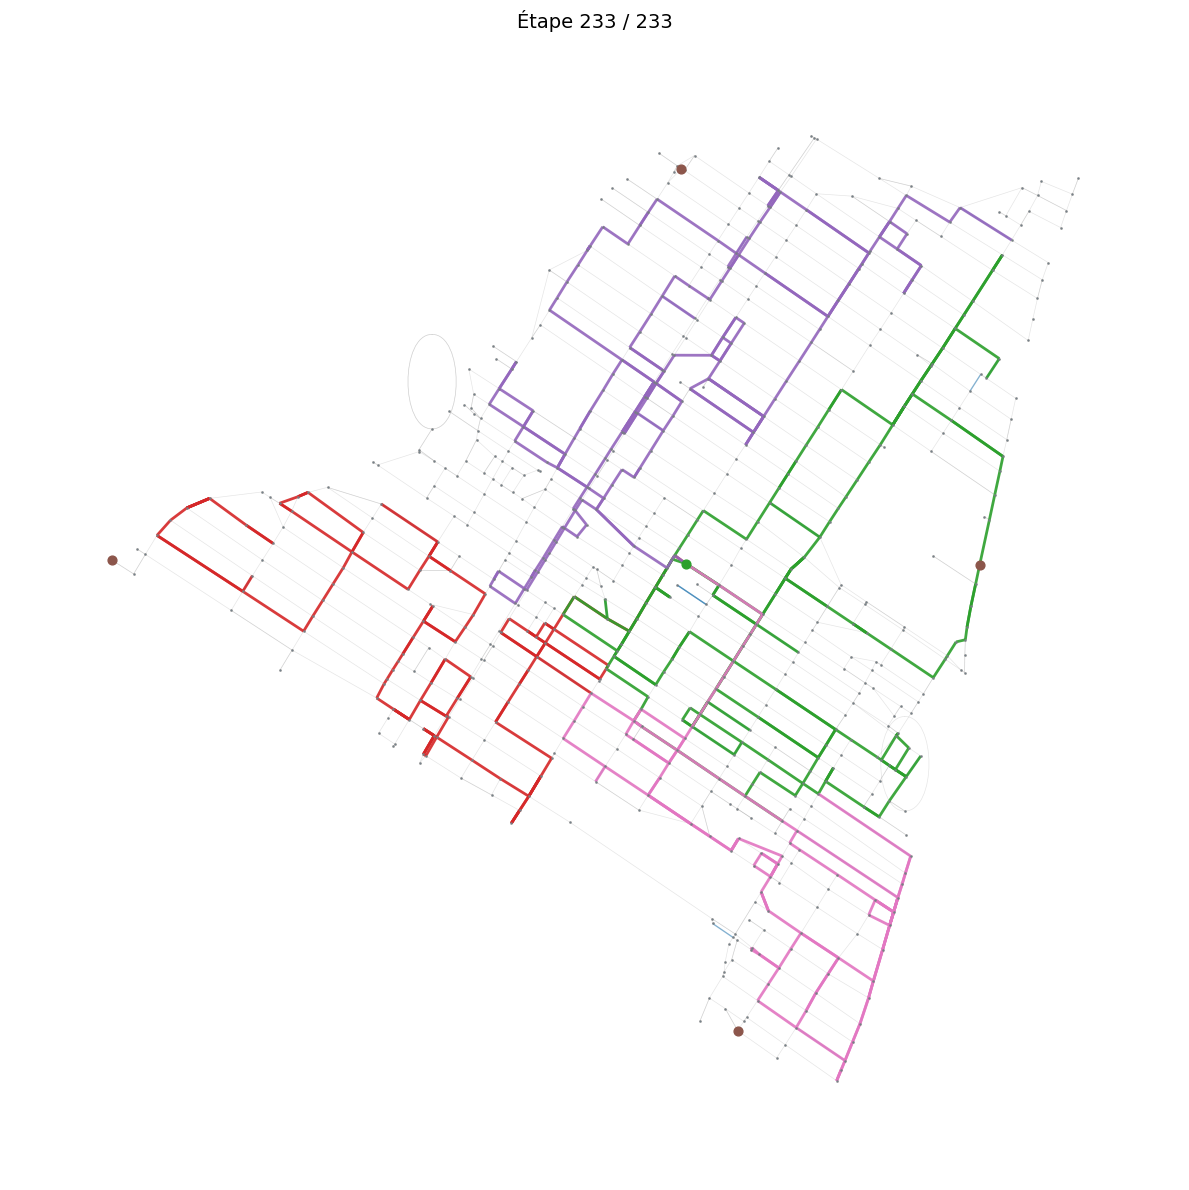

Time elapsed:  207.57 s


In [16]:
start = time.time()

pos = {node: (data['x'], data['y']) for node, data in G_aug.nodes(data=True)}

# Liste des chemins de déneigeuses
paths = [path_charue1, path_charue2, path_charue3, path_charue4]

# Couleurs
colors = ["tab:red", "tab:green", "tab:pink", "tab:purple", "tab:brown" ]

edges_drawn = [[] for i in paths]

max_steps = max(len(p) for p in paths)

for step in range(max_steps):
    clear_output(wait=True)
    plt.figure(figsize=(12, 12))

    options = {"edgecolors": "tab:gray", "node_size": 1, "alpha": 0.8}
    nx.draw_networkx_nodes(G_aug, pos, node_color="tab:blue", **options)
    
    #Afficher les noeuds centraux
    nx.draw_networkx_nodes(G_aug, pos, node_color="tab:green", node_size=40, nodelist=[middle1])
    nx.draw_networkx_nodes(G_aug, pos, node_color="tab:brown", node_size=40, nodelist=[a,b,c,d])
    
    nx.draw_networkx_edges(G_aug, pos, width=0.5, alpha=0.2, edge_color="gray")

    nx.draw_networkx_edges(G_aug, pos, edgelist=snow_edges, width=1, alpha=0.5, edge_color="tab:blue")

    for idx, path in enumerate(paths):
        if step < len(path):
            edges_drawn[idx].append(path[step])
        nx.draw_networkx_edges(
            G_aug,
            pos,
            edgelist=edges_drawn[idx],
            width=2,
            alpha=0.9,
            edge_color=colors[idx]
        )

    plt.title(f"Étape {step+1} / {max_steps}", fontsize=14)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

    print("Time elapsed: ", round(time.time() - start, 2), "s")

#### Exportation pour n deneigeuses

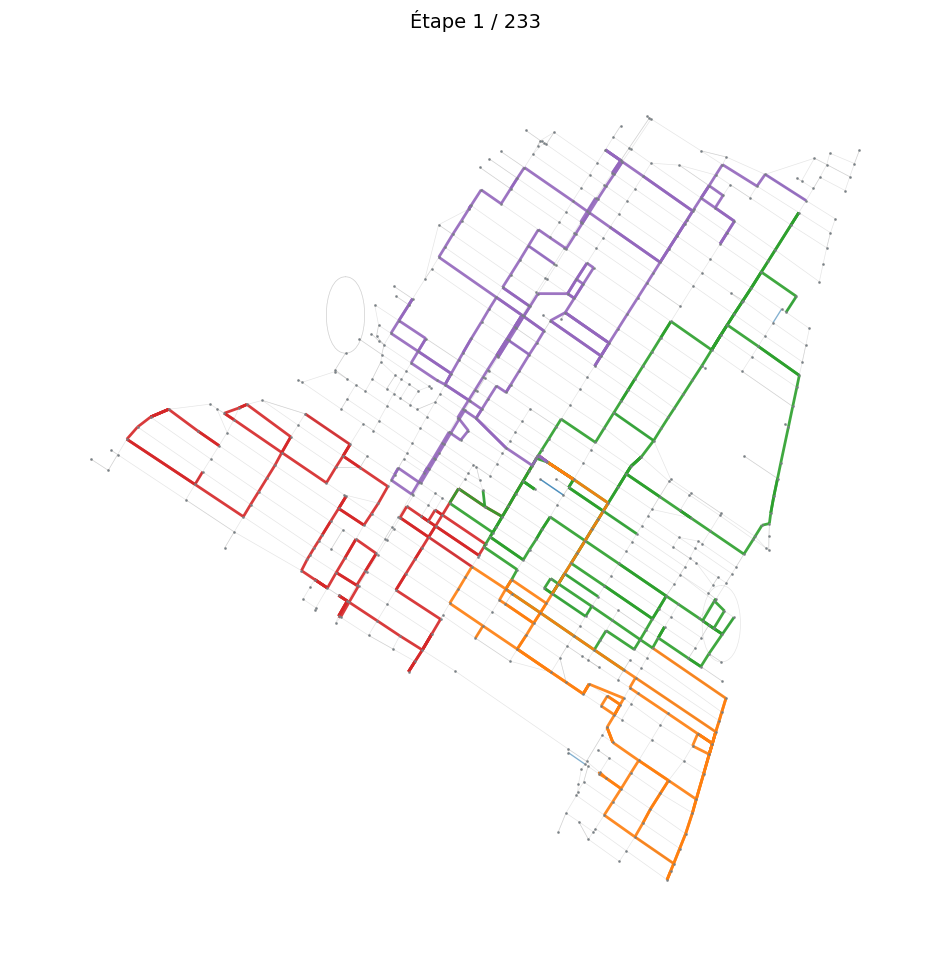

In [17]:
from matplotlib.animation import FuncAnimation, FFMpegWriter

colors = ["tab:red", "tab:green", "tab:orange", "tab:purple", "tab:pink", "tab:brown"]
n = len(paths)
colors = colors[:n]  # limitation simple

max_steps = max(len(p) for p in paths)

fig, ax = plt.subplots(figsize=(12, 12))

edges_drawn = [[] for i in paths]

def update(step):
    ax.clear()

    options = {"edgecolors": "tab:gray", "node_size": 1, "alpha": 0.8}
    nx.draw_networkx_nodes(G_aug, pos, node_color="tab:blue", ax=ax, **options)
    nx.draw_networkx_edges(G_aug, pos, width=0.5, alpha=0.2, edge_color="gray", ax=ax)
    nx.draw_networkx_edges(G_aug, pos, edgelist=snow_edges, width=1, alpha=0.5, edge_color="tab:blue", ax=ax)
    
    for idx, path in enumerate(paths):
        if len(path) > step:
            edges_drawn[idx].append(path[step])
        nx.draw_networkx_edges(
            G_aug,
            pos,
            edgelist=edges_drawn[idx],
            width=2,
            alpha=0.9,
            edge_color=colors[idx]
        )

    ax.set_title(f"Étape {step+1} / {max_steps}", fontsize=14)
    ax.axis("off")

    
anim = FuncAnimation(
        fig, update,
        frames=range(0, max_steps),
        repeat=False
    )


writer = FFMpegWriter(fps=5, bitrate=1800)
anim.save("animations/plateau_mr_4_fin.mp4", writer=writer)

#### Evaluation du parcours
On va maintenant regarder combien coûte à la ville le scénario calculé

In [16]:
def divide_list(l):
    return l[:len(l)/2], l[len(l)/2:]

In [17]:
def edge_dist(G, edge):
    (x,y,n) = edge
    return G[x][y][n]['length']

#edge_dist(G, (5051745574, 31705844, 0))

In [18]:
def get_total_dist(G, edges):
    return sum(map(lambda edge: edge_dist(G, edge), edges))

total = get_total_dist(G, path_charue1)
print("La charue a drivé sur", total/1000, "km.")
print("La charue 1 de type 1 aurait coûté", 500 + (total/1000)/10*1.1 + (total/1000)*1.1, "$.")

La charue a drivé sur 17.097751703433058 km.
La charue 1 de type 1 aurait coûté 520.688279561154 $.
